In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as an
import sys
sys.path.append('/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/AIID_notebooks/')

from inflapy.immunoFunc import *

In [2]:
path = "/nfs/team205/bh14/Datasets/RawData/raw_and_AnnData/annDataModified/curated_anndata/"

s_path = "/nfs/team205/bh14/Datasets/Remapped/raw_adata/ummapped/"

#### Wenjie dataset

In [3]:
adata = sc.read_h5ad(path+"Smillies_et_al_Imm_modified.curated.h5ad")

In [4]:
adata

AnnData object with n_obs × n_vars = 210614 × 20529
    obs: 'assay_sc', 'assay_differentiation', 'assay_type_differentiation', 'bio_sample', 'cell_line', 'cell_type', 'development_stage', 'disease_original', 'ethnicity', 'id', 'individual', 'organ', 'organism', 'sex', 'state_exact', 'sample_source', 'tech_sample', 'subject', 'disease_stage', 'location', 'dataset_id', 'tissue', 'assay_sc_ontology_term_id', 'assay_sc_original', 'cell_line_ontology_term_id', 'cell_line_original', 'cell_type_ontology_term_id', 'cell_type_original', 'development_stage_ontology_term_id', 'development_stage_original', 'disease', 'disease_ontology_term_id', 'ethnicity_ontology_term_id', 'ethnicity_original', 'organ_ontology_term_id', 'organ_original', 'organism_ontology_term_id', 'organism_original', 'sex_ontology_term_id', 'sex_original'
    var: 'ensembl', 'gene_symbol'
    uns: 'annotated', 'assay_differentiation', 'assay_sc', 'assay_type_differentiation', 'author', 'cell_line', 'cell_type', 'default_embed

In [5]:
adata.obs.tissue.value_counts()

Monocyte_BD    25591
Monocyte_HC    22985
PBMC_BD        21406
PBMC_HC        20418
Name: tissue, dtype: int64

In [13]:
adata.obs

,tissue,disease,donor_id,dataset_id
AAACCTGAGCTCAACT-1,Monocyte_BD,Behçet’s disease,Monocyte_BD_1,Wenjie_Zheng_et_al_2022
AAACCTGAGGGCTTGA-1,Monocyte_BD,Behçet’s disease,Monocyte_BD_1,Wenjie_Zheng_et_al_2022
AAACCTGCACAACTGT-1,Monocyte_BD,Behçet’s disease,Monocyte_BD_1,Wenjie_Zheng_et_al_2022
AAACCTGCACAGTCGC-1,Monocyte_BD,Behçet’s disease,Monocyte_BD_1,Wenjie_Zheng_et_al_2022
AAACCTGCAGTTCCCT-1,Monocyte_BD,Behçet’s disease,Monocyte_BD_1,Wenjie_Zheng_et_al_2022
...,...,...,...,...
TTTGTCATCACATGCA-1,PBMC_HC,Control,PBMC_HC_4,Wenjie_Zheng_et_al_2022
TTTGTCATCATCACCC-1,PBMC_HC,Control,PBMC_HC_4,Wenjie_Zheng_et_al_2022
TTTGTCATCCGCAAGC-1,PBMC_HC,Control,PBMC_HC_4,Wenjie_Zheng_et_al_2022
TTTGTCATCTGAAAGA-1-1,PBMC_HC,Control,PBMC_HC_4,Wenjie_Zheng_et_al_2022


In [21]:
adata.obs["cell_source"] = adata.obs["tissue"].str.replace("_HC", "").str.replace("_BD", "")

In [22]:
adata.obs["tissue"] = np.repeat("Blood", adata.n_obs)

In [23]:
adata.obs

,tissue,disease,donor_id,dataset_id,cell_source
AAACCTGAGCTCAACT-1,Blood,Behçet’s disease,Monocyte_BD_1,Wenjie_Zheng_et_al_2022,Monocyte
AAACCTGAGGGCTTGA-1,Blood,Behçet’s disease,Monocyte_BD_1,Wenjie_Zheng_et_al_2022,Monocyte
AAACCTGCACAACTGT-1,Blood,Behçet’s disease,Monocyte_BD_1,Wenjie_Zheng_et_al_2022,Monocyte
AAACCTGCACAGTCGC-1,Blood,Behçet’s disease,Monocyte_BD_1,Wenjie_Zheng_et_al_2022,Monocyte
AAACCTGCAGTTCCCT-1,Blood,Behçet’s disease,Monocyte_BD_1,Wenjie_Zheng_et_al_2022,Monocyte
...,...,...,...,...,...
TTTGTCATCACATGCA-1,Blood,Control,PBMC_HC_4,Wenjie_Zheng_et_al_2022,PBMC
TTTGTCATCATCACCC-1,Blood,Control,PBMC_HC_4,Wenjie_Zheng_et_al_2022,PBMC
TTTGTCATCCGCAAGC-1,Blood,Control,PBMC_HC_4,Wenjie_Zheng_et_al_2022,PBMC
TTTGTCATCTGAAAGA-1-1,Blood,Control,PBMC_HC_4,Wenjie_Zheng_et_al_2022,PBMC


In [24]:
gc.collect()

18267

In [25]:
temp = sc.read("/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_celltypist_scvbi_donor_as_batch.h5ad",
              backed='r')

In [27]:
temp.var_names

Index(['HES4', 'ISG15', 'TNFRSF18', 'TNFRSF4', 'MRPL20-AS1', 'PRDM16', 'PHF13',
       'RBP7', 'KIF1B', 'CDA',
       ...
       'SSR4', 'TKTL1', 'FLNA', 'MPP1', 'TMLHE', 'RPS4Y1', 'MT-CO3', 'MT-ND5',
       'AC233755.2', 'AC233755.1'],
      dtype='object', length=2000)

In [28]:
comm = [gene for gene in adata.var_names if gene in temp.var_names]

In [29]:
len(comm)

1511

In [27]:
### Wenjie have been removed. Very different of the reference dataset

In [3]:
adata = sc.read_h5ad(s_path+"PBMC/Perez_2022_flare_treated_Healthy.h5ad")

#####################################################
###                      Perez_2022_flare_treated_Healthy                 ###
######################################################
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.59
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.3%
Overall doublet rate:
	Expected   = 7.6%
	Estimated  = 1.6%
Elapsed time: 4638.7 seconds
Pass       567025
Doublet        25
Name: QC, dtype: int64
Plot of metadata only for cells that pass tentative QC:  



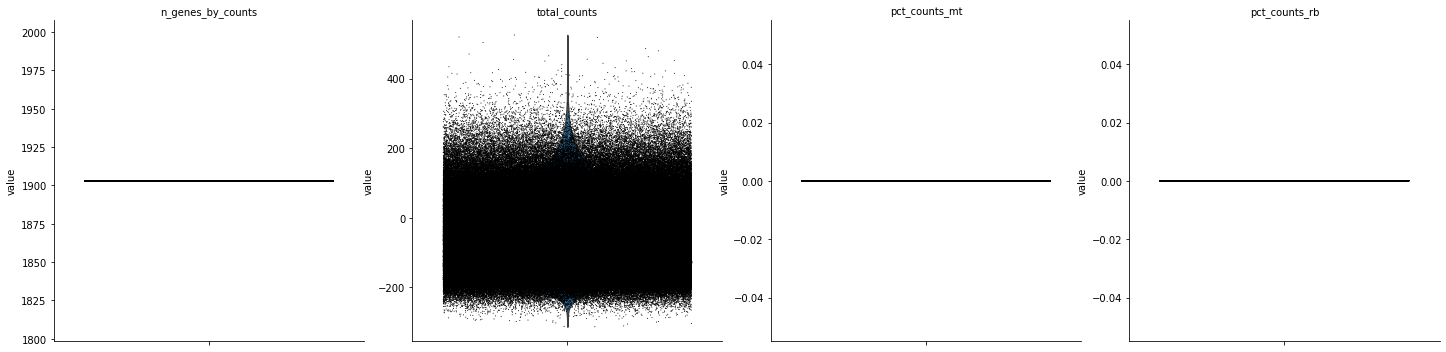

In [4]:
adataQc(adata=adata, path=s_path+"PBMC/QC_Doublet/", file="Perez_2022_flare_treated_Healthy")

In [5]:
adata.obs.donor_id.value_counts()

d6b9e3a7-9f15-4931-a07d-4f4a03991d68    13543
1d15a70f-8b4c-4d49-a08b-c7098cd3b170    12768
79dd16e4-4d95-445f-a2b8-2d2e10872774    12491
4ea8244c-06f7-49b6-b246-63195f85a392    11178
03b233c8-d3e2-4438-8b04-0b6621fb5635    10382
                                        ...  
e3d72ad1-03a0-4358-9dc6-cec4b8018512     1899
1bed79e5-39d1-461e-a189-7a70e95b250d     1810
2a3821dd-89d1-4f22-b36e-6d2630e71e16     1487
88e90be3-39e5-4a3b-9218-6f849e4dc8db     1189
94ac9d2f-36bb-4998-8213-dde641efebb1      456
Name: donor_id, Length: 118, dtype: int64